In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot
import seaborn as sns

In [2]:
df = pd.read_csv('train.txt', sep=';',header=None, names = ['text','emotion'])

In [3]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [5]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
i = 0
for emo in unique_emotions:
    emotion_numbers[emo] = i
    i += 1

df['emotion'] = df['emotion'].map(emotion_numbers)

df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [6]:
# 1. all text to lowercase
df['text'] = df['text'].apply(lambda x : x.lower())

## Exploratory Data Analysis (EDA)
In this section, we will analyze the distribution of emotions and the length of the text entries to better understand our dataset.

C:\Users\maver\AppData\Local\Temp\ipykernel_6432\3517202230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', palette='viridis')


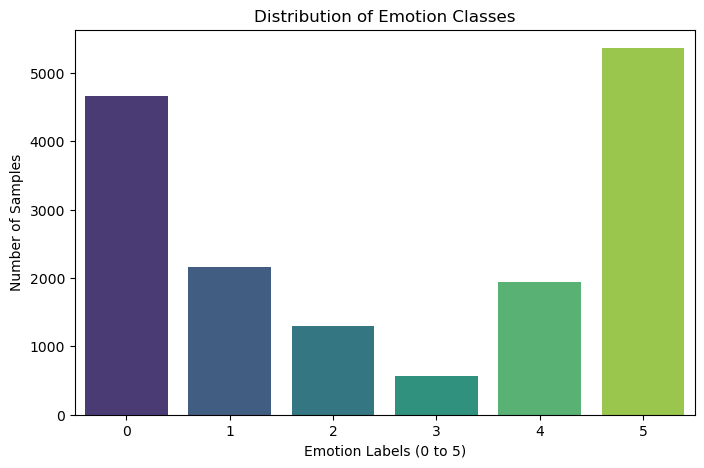

emotion
5    5362
0    4666
1    2159
4    1937
2    1304
3     572
Name: count, dtype: int64


In [31]:
# plotting distribution of mapped emotion class
matplotlib.pyplot.figure(figsize=(8,5))
sns.countplot(data=df, x='emotion', palette='viridis')
matplotlib.pyplot.title('Distribution of Emotion Classes')
matplotlib.pyplot.xlabel('Emotion Labels (0 to 5)')
matplotlib.pyplot.ylabel('Number of Samples')
matplotlib.pyplot.show()

# exact counts 
print(df['emotion'].value_counts())

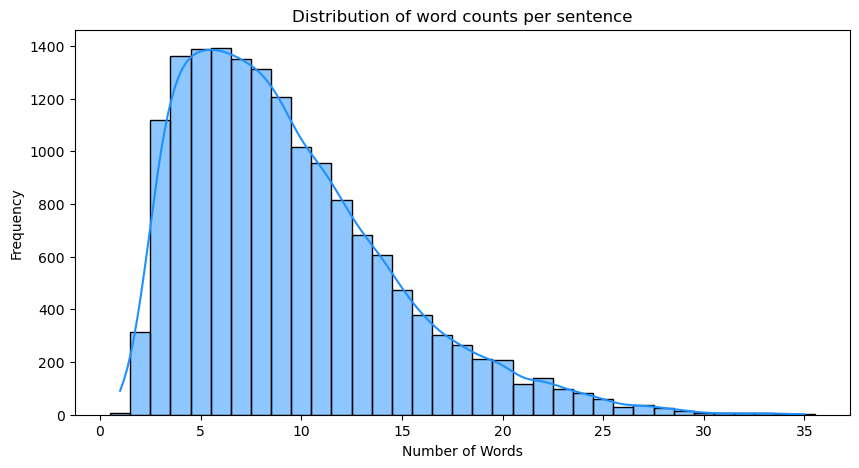

count    16000.000000
mean         9.353063
std          5.213083
min          1.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         35.000000
Name: word_count, dtype: float64


In [33]:
# creating new column for word count
df['word_count'] = df['text'].apply(lambda x : len(x.split()))

# Plot word counts' distribution
matplotlib.pyplot.figure(figsize=(10,5))
sns.histplot(df['word_count'], discrete=True, kde=True, color='dodgerblue')
matplotlib.pyplot.title('Distribution of word counts per sentence')
matplotlib.pyplot.xlabel('Number of Words')
matplotlib.pyplot.ylabel('Frequency')
matplotlib.pyplot.show()

print(df['word_count'].describe())

In [34]:
!pip install wordcloud

In [7]:
# 2. remove punctuation 
import string
def remove_punc(txt):
    return txt.translate(str.maketrans('','',string.punctuation))

df['text'] = df['text'].apply(remove_punc)

In [8]:
# 3. remove numbers
def remove_numbers(txt):
    new = ''
    for i in txt:
        if not i.isdigit():
            new = new + i
    return new

df['text'] = df['text'].apply(remove_numbers)

In [9]:
 # 4. remove urls/links

In [10]:
# 6. remove emotions
def remove_emojis(txt):
    new = ''
    for i in txt:
        if i.isascii():
            new += i
    return new

df['text'] = df['text'].apply(remove_emojis)

In [11]:
# 7. remove stopwords --> for ML
# nltk : natural language toolkit
# spaCy

# corpus : collection of texts 
# sentence : group of words forms a meaning ful statements
# token : each individual word or symbol


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [12]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\maver\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maver\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
stop_words = set(stopwords.words('english'))
len(stop_words)

198

In [14]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [15]:
def remove(txt):
    words = txt.split()
    cleaned = []
    for i in words:
        if not i in stop_words:
            cleaned.append(i)

    return ' '.join(cleaned)


df['text'] = df['text'].apply(remove)

In [16]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [17]:
# data spliting

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'],df['emotion'], test_size=0.20, random_state=42)

In [18]:
# vectorization 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [19]:
# bag of words
bow_vectorizer = CountVectorizer()

In [22]:
# Fit and transform the training data
X_train_bow = bow_vectorizer.fit_transform(X_train)

# ONLY transform the test data (do not fit)
X_test_bow = bow_vectorizer.transform(X_test)

In [23]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

pred_bow = nb_model.predict(X_test_bow)
print(accuracy_score(y_test,pred_bow))

0.768125


In [26]:
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# ONLY transform the test data (do not fit)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf,y_train)

MultinomialNB()

In [27]:
y_pred = nb2_model.predict(X_test_tfidf)
print(accuracy_score(y_test,y_pred))

0.6609375


In [28]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [30]:
log_pred = logistic_model.predict(X_test_tfidf)
print(accuracy_score(y_test, log_pred))

0.8628125
